In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ankansamanta980/happy-face/happy_face.jpeg
/kaggle/input/datasets/ankansamanta980/surprise-img/surprise_img.jpeg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/test_labels.csv
/kaggle/input/datasets/shuvoalok/raf-db-dataset/train_labels.csv
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2941_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2717_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2499_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2724_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2935_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2419_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2779_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test/7/test_2566_aligned.jpg
/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET

In [2]:
import os

root = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET"

print("Root exists:", os.path.exists(root))
print("Folders inside DATASET:", os.listdir(root))
print("Train classes:", os.listdir(os.path.join(root, "train")))
print("Test classes:", os.listdir(os.path.join(root, "test")))

Root exists: True
Folders inside DATASET: ['test', 'train']
Train classes: ['7', '2', '5', '3', '1', '4', '6']
Test classes: ['7', '2', '5', '3', '1', '4', '6']


In [3]:
import os
import pandas as pd

# =========================
# RAF-DB root folders
# =========================
train_root = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train"
test_root  = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test"

# RAF-DB class folders
class_folders = ['1', '2', '3', '4', '5', '6', '7']

# map folder names to 0..6 labels
label_map = {cls_name: idx for idx, cls_name in enumerate(class_folders)}

all_data = []

# ---------- collect train images ----------
for cls_name in class_folders:
    class_path = os.path.join(train_root, cls_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        all_data.append([img_path, label_map[cls_name]])

# ---------- collect test images ----------
for cls_name in class_folders:
    class_path = os.path.join(test_root, cls_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        all_data.append([img_path, label_map[cls_name]])

# ---------- make dataframe ----------
df = pd.DataFrame(all_data, columns=["image_path", "label"])

print("Total images in full RAF-DB:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts().sort_index())

print("\nFirst 5 rows:")
print(df.head())

Total images in full RAF-DB: 15339

Class distribution:
label
0    1619
1     355
2     877
3    5957
4    2460
5     867
6    3204
Name: count, dtype: int64

First 5 rows:
                                          image_path  label
0  /kaggle/input/datasets/shuvoalok/raf-db-datase...      0
1  /kaggle/input/datasets/shuvoalok/raf-db-datase...      0
2  /kaggle/input/datasets/shuvoalok/raf-db-datase...      0
3  /kaggle/input/datasets/shuvoalok/raf-db-datase...      0
4  /kaggle/input/datasets/shuvoalok/raf-db-datase...      0


In [4]:
from sklearn.model_selection import train_test_split

# =========================
# 70:30 stratified split
# =========================
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# reset index for clean access later
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size :", len(test_df))

print("\nTrain class distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df["label"].value_counts().sort_index())

Train size: 10737
Test size : 4602

Train class distribution:
label
0    1133
1     248
2     614
3    4170
4    1722
5     607
6    2243
Name: count, dtype: int64

Test class distribution:
label
0     486
1     107
2     263
3    1787
4     738
5     260
6     961
Name: count, dtype: int64


In [5]:
from torch.utils.data import Dataset
from PIL import Image

class RAFCustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["image_path"]
        label = int(self.dataframe.iloc[idx]["label"])

        # open image as RGB
        image = Image.open(img_path).convert("RGB")

        # apply transform if given
        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# CustomCNN transforms
# =========================
cnn_train_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

cnn_test_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# CustomCNN datasets
# =========================
cnn_train_dataset = RAFCustomDataset(train_df, transform=cnn_train_transform)
cnn_test_dataset  = RAFCustomDataset(test_df, transform=cnn_test_transform)

# =========================
# CustomCNN dataloaders
# =========================
cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=32, shuffle=True)
cnn_test_loader  = DataLoader(cnn_test_dataset, batch_size=32, shuffle=False)

print("CNN Train samples:", len(cnn_train_dataset))
print("CNN Test samples :", len(cnn_test_dataset))

Device: cuda
CNN Train samples: 10737
CNN Test samples : 4602


In [7]:
import torch.nn as nn

class CustomCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.fc(x)

cnn_model = CustomCNN(num_classes=7).to(device)
print("Fresh CNN model created")

Fresh CNN model created


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

# =========================
# Loss, optimizer, scheduler
# =========================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

epochs = 80

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)

# =========================
# Early Stopping class
# =========================
class EarlyStopping:
    def __init__(self, patience=10):
        self.patience = patience
        self.best_score = None
        self.counter = 0
        self.stop = False

    def __call__(self, score):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

# =========================
# Training settings
# =========================
epochs = 80
early_stopping = EarlyStopping(patience=10)

train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []

best_test_acc = 0

# =========================
# Training loop
# =========================
for epoch in range(epochs):

    # ---------- TRAIN ----------
    cnn_model.train()
    running_train_loss = 0
    correct = 0
    total = 0

    for images, labels in cnn_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_train_loss / len(cnn_train_loader)

    # ---------- TEST ----------
    cnn_model.eval()
    running_test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in cnn_test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = cnn_model(images)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    test_acc = 100 * correct / total
    test_loss = running_test_loss / len(cnn_test_loader)

    scheduler.step()

    # save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(cnn_model.state_dict(), "/kaggle/working/best_cnn_70_30.pth")

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}\n")

    # ---------- Early stopping check ----------
    early_stopping(test_acc)
    if early_stopping.stop:
        print("Early stopping triggered")
        break

print("Best CNN Test Accuracy:", best_test_acc)
print("Saved model: /kaggle/working/best_cnn_70_30.pth")

Epoch 1/80
Train Acc: 36.62 | Test Acc: 38.83
Train Loss: 1.8404 | Test Loss: 1.6532

Epoch 2/80
Train Acc: 38.82 | Test Acc: 38.83
Train Loss: 1.6929 | Test Loss: 1.5776

Epoch 3/80
Train Acc: 38.83 | Test Acc: 38.83
Train Loss: 1.6580 | Test Loss: 1.5688

Epoch 4/80
Train Acc: 40.09 | Test Acc: 42.44
Train Loss: 1.6210 | Test Loss: 1.5417

Epoch 5/80
Train Acc: 43.55 | Test Acc: 51.59
Train Loss: 1.5991 | Test Loss: 1.4817

Epoch 6/80
Train Acc: 44.91 | Test Acc: 50.85
Train Loss: 1.5818 | Test Loss: 1.4819

Epoch 7/80
Train Acc: 45.58 | Test Acc: 51.74
Train Loss: 1.5649 | Test Loss: 1.4592

Epoch 8/80
Train Acc: 46.23 | Test Acc: 52.82
Train Loss: 1.5560 | Test Loss: 1.4787

Epoch 9/80
Train Acc: 46.49 | Test Acc: 52.30
Train Loss: 1.5418 | Test Loss: 1.4334

Epoch 10/80
Train Acc: 46.42 | Test Acc: 51.67
Train Loss: 1.5438 | Test Loss: 1.4745

Epoch 11/80
Train Acc: 46.61 | Test Acc: 52.06
Train Loss: 1.5418 | Test Loss: 1.4589

Epoch 12/80
Train Acc: 47.02 | Test Acc: 53.11
Train

In [9]:
import numpy as np
import torch
import torch.nn.functional as F

# =========================
# Load best saved CNN model
# =========================
cnn_model = CustomCNN(num_classes=7).to(device)
cnn_model.load_state_dict(torch.load("/kaggle/working/best_cnn_70_30.pth"))
cnn_model.eval()

cnn_probs = []
cnn_preds = []
cnn_true  = []

with torch.no_grad():
    for images, labels in cnn_test_loader:
        images = images.to(device)

        outputs = cnn_model(images)
        probs = F.softmax(outputs, dim=1)

        cnn_probs.extend(probs.cpu().numpy())
        cnn_preds.extend(torch.argmax(probs, dim=1).cpu().numpy())
        cnn_true.extend(labels.numpy())

cnn_probs = np.array(cnn_probs)
cnn_preds = np.array(cnn_preds)
cnn_true  = np.array(cnn_true)

print("CNN probabilities shape :", cnn_probs.shape)
print("CNN predictions shape   :", cnn_preds.shape)
print("CNN true labels shape   :", cnn_true.shape)

# CNN accuracy from extracted predictions
cnn_acc = (cnn_preds == cnn_true).mean() * 100
print(f"\nCNN Accuracy from saved model: {cnn_acc:.2f}%")

CNN probabilities shape : (4602, 7)
CNN predictions shape   : (4602,)
CNN true labels shape   : (4602,)

CNN Accuracy from saved model: 75.34%


In [10]:
from torchvision import transforms
from torch.utils.data import DataLoader

# =========================
# ResNet50 transforms
# =========================
resnet_train_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

resnet_test_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# ResNet50 datasets
# =========================
resnet_train_dataset = RAFCustomDataset(train_df, transform=resnet_train_transform)
resnet_test_dataset  = RAFCustomDataset(test_df, transform=resnet_test_transform)

# =========================
# ResNet50 dataloaders
# =========================
resnet_train_loader = DataLoader(resnet_train_dataset, batch_size=16, shuffle=True)
resnet_test_loader  = DataLoader(resnet_test_dataset, batch_size=16, shuffle=False)

print("ResNet Train samples:", len(resnet_train_dataset))
print("ResNet Test samples :", len(resnet_test_dataset))

ResNet Train samples: 10737
ResNet Test samples : 4602


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================
# ResNet50 Bottleneck Block
# =========================
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion,
                               kernel_size=1, bias=False)
        self.bn3   = nn.BatchNorm2d(out_channels * self.expansion)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        return F.relu(out)

# =========================
# ResNet50 Model
# =========================
class ResNet50Scratch(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64,  3, stride=1)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512 * 4, num_classes)   # 2048 -> 7

    def _make_layer(self, out_channels, blocks, stride):
        layers = []
        layers.append(Bottleneck(self.in_channels, out_channels, stride))
        self.in_channels = out_channels * 4

        for _ in range(1, blocks):
            layers.append(Bottleneck(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = F.adaptive_avg_pool2d(x, (1,1))
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# create model
resnet_model = ResNet50Scratch(num_classes=7).to(device)

print(resnet_model)

ResNet50Scratch(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

# =========================
# Loss, optimizer, scheduler
# =========================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    resnet_model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

epochs = 50

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

# =========================
# Early Stopping
# =========================
class EarlyStopping:
    def __init__(self, patience=8):
        self.patience = patience
        self.best_score = None
        self.counter = 0
        self.stop = False

    def __call__(self, score):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

early_stopping = EarlyStopping(patience=8)

# =========================
# Training storage
# =========================
resnet_train_acc_list = []
resnet_test_acc_list = []
resnet_train_loss_list = []
resnet_test_loss_list = []

best_test_acc = 0

# =========================
# Training loop
# =========================
for epoch in range(epochs):

    # ---------- TRAIN ----------
    resnet_model.train()
    running_train_loss = 0
    correct = 0
    total = 0

    for images, labels in resnet_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = resnet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_train_loss / len(resnet_train_loader)

    # ---------- TEST ----------
    resnet_model.eval()
    running_test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in resnet_test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet_model(images)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    test_acc = 100 * correct / total
    test_loss = running_test_loss / len(resnet_test_loader)

    scheduler.step()

    # save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(resnet_model.state_dict(), "/kaggle/working/best_resnet50_70_30.pth")

    resnet_train_acc_list.append(train_acc)
    resnet_test_acc_list.append(test_acc)
    resnet_train_loss_list.append(train_loss)
    resnet_test_loss_list.append(test_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}\n")

    # ---------- Early stopping ----------
    early_stopping(test_acc)
    if early_stopping.stop:
        print("Early stopping triggered")
        break

print("Best ResNet50 Test Accuracy:", best_test_acc)
print("Saved model: /kaggle/working/best_resnet50_70_30.pth")

Epoch 1/50
Train Acc: 40.51 | Test Acc: 47.22
Train Loss: 1.7810 | Test Loss: 2.4344

Epoch 2/50
Train Acc: 49.71 | Test Acc: 41.44
Train Loss: 1.5278 | Test Loss: 1.8649

Epoch 3/50
Train Acc: 53.88 | Test Acc: 56.45
Train Loss: 1.4161 | Test Loss: 1.4050

Epoch 4/50
Train Acc: 59.52 | Test Acc: 57.69
Train Loss: 1.3075 | Test Loss: 1.3511

Epoch 5/50
Train Acc: 62.31 | Test Acc: 62.23
Train Loss: 1.2486 | Test Loss: 1.2847

Epoch 6/50
Train Acc: 64.97 | Test Acc: 61.99
Train Loss: 1.1905 | Test Loss: 1.2597

Epoch 7/50
Train Acc: 65.85 | Test Acc: 67.97
Train Loss: 1.1743 | Test Loss: 1.1288

Epoch 8/50
Train Acc: 67.22 | Test Acc: 68.86
Train Loss: 1.1443 | Test Loss: 1.1057

Epoch 9/50
Train Acc: 67.95 | Test Acc: 70.12
Train Loss: 1.1196 | Test Loss: 1.0974

Epoch 10/50
Train Acc: 68.46 | Test Acc: 70.01
Train Loss: 1.1146 | Test Loss: 1.0922

Epoch 11/50
Train Acc: 72.39 | Test Acc: 74.10
Train Loss: 1.0370 | Test Loss: 1.0108

Epoch 12/50
Train Acc: 74.99 | Test Acc: 73.34
Train

In [13]:
import numpy as np
import torch
import torch.nn.functional as F

# =========================
# Load best saved ResNet50 model
# =========================
resnet_model = ResNet50Scratch(num_classes=7).to(device)
resnet_model.load_state_dict(torch.load("/kaggle/working/best_resnet50_70_30.pth"))
resnet_model.eval()

resnet_probs = []
resnet_preds = []
resnet_true  = []

with torch.no_grad():
    for images, labels in resnet_test_loader:
        images = images.to(device)

        outputs = resnet_model(images)
        probs = F.softmax(outputs, dim=1)

        resnet_probs.extend(probs.cpu().numpy())
        resnet_preds.extend(torch.argmax(probs, dim=1).cpu().numpy())
        resnet_true.extend(labels.numpy())

resnet_probs = np.array(resnet_probs)
resnet_preds = np.array(resnet_preds)
resnet_true  = np.array(resnet_true)

print("ResNet probabilities shape :", resnet_probs.shape)
print("ResNet predictions shape   :", resnet_preds.shape)
print("ResNet true labels shape   :", resnet_true.shape)

resnet_acc = (resnet_preds == resnet_true).mean() * 100
print(f"\nResNet50 Accuracy from saved model: {resnet_acc:.2f}%")

ResNet probabilities shape : (4602, 7)
ResNet predictions shape   : (4602,)
ResNet true labels shape   : (4602,)

ResNet50 Accuracy from saved model: 79.18%


In [14]:
from torchvision import transforms
from torch.utils.data import DataLoader

# =========================
# EfficientNet transforms
# =========================
eff_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.RandomAffine(degrees=0, shear=10, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eff_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# =========================
# EfficientNet datasets
# =========================
eff_train_dataset = RAFCustomDataset(train_df, transform=eff_train_transform)
eff_test_dataset  = RAFCustomDataset(test_df, transform=eff_test_transform)

# =========================
# EfficientNet dataloaders
# =========================
eff_train_loader = DataLoader(eff_train_dataset, batch_size=32, shuffle=True)
eff_test_loader  = DataLoader(eff_test_dataset, batch_size=32, shuffle=False)

print("EfficientNet Train samples:", len(eff_train_dataset))
print("EfficientNet Test samples :", len(eff_test_dataset))

EfficientNet Train samples: 10737
EfficientNet Test samples : 4602


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================
# Swish Activation
# =========================
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

# =========================
# Drop Connect
# =========================
def drop_connect(x, drop_prob, training):
    if not training or drop_prob == 0:
        return x
    keep_prob = 1 - drop_prob
    random_tensor = keep_prob + torch.rand([x.shape[0], 1, 1, 1], device=x.device)
    binary_mask = torch.floor(random_tensor)
    return x / keep_prob * binary_mask

# =========================
# Squeeze-and-Excitation Block
# =========================
class SEBlock(nn.Module):
    def __init__(self, in_c):
        super().__init__()
        self.fc1 = nn.Conv2d(in_c, in_c // 4, 1)
        self.fc2 = nn.Conv2d(in_c // 4, in_c, 1)

    def forward(self, x):
        y = F.adaptive_avg_pool2d(x, 1)
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y))
        return x * y

# =========================
# MBConv Block
# =========================
class MBConv(nn.Module):
    def __init__(self, in_c, out_c, exp, stride, drop_rate):
        super().__init__()
        self.use_res = (in_c == out_c and stride == 1)
        hidden = in_c * exp

        self.expand = nn.Sequential(
            nn.Conv2d(in_c, hidden, 1, bias=False),
            nn.BatchNorm2d(hidden),
            Swish()
        ) if exp != 1 else nn.Identity()

        self.depthwise = nn.Sequential(
            nn.Conv2d(hidden, hidden, 3, stride, 1, groups=hidden, bias=False),
            nn.BatchNorm2d(hidden),
            Swish()
        )

        self.se = SEBlock(hidden)

        self.project = nn.Sequential(
            nn.Conv2d(hidden, out_c, 1, bias=False),
            nn.BatchNorm2d(out_c)
        )

        self.drop_rate = drop_rate

    def forward(self, x):
        out = self.expand(x)
        out = self.depthwise(out)
        out = self.se(out)
        out = self.project(out)

        if self.use_res:
            out = drop_connect(out, self.drop_rate, self.training)
            return x + out
        return out

# =========================
# EfficientNet-B0
# =========================
class EfficientNet_B0(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            Swish()
        )

        self.blocks = nn.Sequential(
            MBConv(32, 16, 1, 1, 0.2),

            MBConv(16, 24, 6, 2, 0.2),
            MBConv(24, 24, 6, 1, 0.2),

            MBConv(24, 40, 6, 2, 0.2),
            MBConv(40, 40, 6, 1, 0.2),

            MBConv(40, 80, 6, 2, 0.2),
            MBConv(80, 80, 6, 1, 0.2),
            MBConv(80, 80, 6, 1, 0.2),

            MBConv(80, 112, 6, 1, 0.2),
            MBConv(112, 112, 6, 1, 0.2),

            MBConv(112, 192, 6, 2, 0.2),
            MBConv(192, 192, 6, 1, 0.2),
            MBConv(192, 192, 6, 1, 0.2),

            MBConv(192, 320, 6, 1, 0.2),
        )

        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, 1, bias=False),
            nn.BatchNorm2d(1280),
            Swish(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

# create model
eff_model = EfficientNet_B0(num_classes=7).to(device)

print("EfficientNet model created")
print(eff_model)

EfficientNet model created
EfficientNet_B0(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Swish()
  )
  (blocks): Sequential(
    (0): MBConv(
      (expand): Identity()
      (depthwise): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Swish()
      )
      (se): SEBlock(
        (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
        (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
      )
      (project): Sequential(
        (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): MBConv(
      (expand): Sequential(
  

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

# =========================
# Loss, optimizer, scheduler
# =========================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    eff_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

# =========================
# Early Stopping
# =========================
class EarlyStopping:
    def __init__(self, patience=10):
        self.best = None
        self.count = 0
        self.stop = False
        self.patience = patience

    def __call__(self, val_loss):
        if self.best is None or val_loss < self.best:
            self.best = val_loss
            self.count = 0
        else:
            self.count += 1
            if self.count >= self.patience:
                self.stop = True

# =========================
# Training settings
# =========================
epochs = 80
early = EarlyStopping(patience=10)

eff_train_acc_list = []
eff_test_acc_list = []
eff_train_loss_list = []
eff_test_loss_list = []

best_test_acc = 0

# =========================
# Training loop
# =========================
for epoch in range(epochs):

    # ---------- TRAIN ----------
    eff_model.train()
    correct = 0
    total = 0
    running_train_loss = 0

    for images, labels in eff_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = eff_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, preds = outputs.max(1)
        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_train_loss / len(eff_train_loader)

    # ---------- TEST ----------
    eff_model.eval()
    correct = 0
    total = 0
    running_test_loss = 0

    with torch.no_grad():
        for images, labels in eff_test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = eff_model(images)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item()

            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    test_acc = 100 * correct / total
    test_loss = running_test_loss / len(eff_test_loader)

    scheduler.step(test_loss)

    # save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(eff_model.state_dict(), "/kaggle/working/best_efficientnet_70_30.pth")

    eff_train_acc_list.append(train_acc)
    eff_test_acc_list.append(test_acc)
    eff_train_loss_list.append(train_loss)
    eff_test_loss_list.append(test_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}\n")

    # ---------- Early stopping ----------
    early(test_loss)
    if early.stop:
        print("Early stopping triggered")
        break

print("Best EfficientNet Test Accuracy:", best_test_acc)
print("Saved model: /kaggle/working/best_efficientnet_70_30.pth")

Epoch 1/80
Train Acc: 37.22 | Test Acc: 39.55
Train Loss: 1.6698 | Test Loss: 1.5997

Epoch 2/80
Train Acc: 39.50 | Test Acc: 40.79
Train Loss: 1.6032 | Test Loss: 1.5804

Epoch 3/80
Train Acc: 41.16 | Test Acc: 45.33
Train Loss: 1.5620 | Test Loss: 1.4662

Epoch 4/80
Train Acc: 44.82 | Test Acc: 50.00
Train Loss: 1.4747 | Test Loss: 1.3583

Epoch 5/80
Train Acc: 48.62 | Test Acc: 52.33
Train Loss: 1.3832 | Test Loss: 1.2933

Epoch 6/80
Train Acc: 52.06 | Test Acc: 58.11
Train Loss: 1.3029 | Test Loss: 1.1816

Epoch 7/80
Train Acc: 55.12 | Test Acc: 60.89
Train Loss: 1.2288 | Test Loss: 1.1124

Epoch 8/80
Train Acc: 57.48 | Test Acc: 62.86
Train Loss: 1.1760 | Test Loss: 1.0537

Epoch 9/80
Train Acc: 58.91 | Test Acc: 62.84
Train Loss: 1.1227 | Test Loss: 1.0326

Epoch 10/80
Train Acc: 61.57 | Test Acc: 65.19
Train Loss: 1.0774 | Test Loss: 0.9907

Epoch 11/80
Train Acc: 62.55 | Test Acc: 66.86
Train Loss: 1.0367 | Test Loss: 0.9449

Epoch 12/80
Train Acc: 64.30 | Test Acc: 68.41
Train

In [17]:
import numpy as np
import torch
import torch.nn.functional as F

# =========================
# Load best saved EfficientNet model
# =========================
eff_model = EfficientNet_B0(num_classes=7).to(device)
eff_model.load_state_dict(torch.load("/kaggle/working/best_efficientnet_70_30.pth"))
eff_model.eval()

eff_probs = []
eff_preds = []
eff_true  = []

with torch.no_grad():
    for images, labels in eff_test_loader:
        images = images.to(device)

        outputs = eff_model(images)
        probs = F.softmax(outputs, dim=1)

        eff_probs.extend(probs.cpu().numpy())
        eff_preds.extend(torch.argmax(probs, dim=1).cpu().numpy())
        eff_true.extend(labels.numpy())

eff_probs = np.array(eff_probs)
eff_preds = np.array(eff_preds)
eff_true  = np.array(eff_true)

print("EfficientNet probabilities shape :", eff_probs.shape)
print("EfficientNet predictions shape   :", eff_preds.shape)
print("EfficientNet true labels shape   :", eff_true.shape)

eff_acc = (eff_preds == eff_true).mean() * 100
print(f"\nEfficientNet Accuracy from saved model: {eff_acc:.2f}%")

EfficientNet probabilities shape : (4602, 7)
EfficientNet predictions shape   : (4602,)
EfficientNet true labels shape   : (4602,)

EfficientNet Accuracy from saved model: 80.47%


In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# =========================================================
# 1) Basic checks
# =========================================================
print("cnn_probs shape     :", cnn_probs.shape)
print("resnet_probs shape  :", resnet_probs.shape)
print("eff_probs shape     :", eff_probs.shape)
print("cnn_true shape      :", cnn_true.shape)

# make sure all true labels are same
assert np.array_equal(cnn_true, resnet_true), "CNN and ResNet true labels do not match!"
assert np.array_equal(cnn_true, eff_true), "CNN and EfficientNet true labels do not match!"

y_true = cnn_true.copy()

# =========================================================
# 2) DST helper functions
# =========================================================
def softmax_to_mass(prob_vector):
    """
    Convert softmax probabilities into mass function dictionary.
    Example output:
    {
        0: p0,
        1: p1,
        ...
        6: p6
    }
    """
    mass = {}
    for i, p in enumerate(prob_vector):
        mass[i] = float(p)
    return mass


def dst_combine_two(m1, m2, num_classes=7):
    """
    Simple DST combination for singleton class masses.
    m1, m2 are dictionaries like {0:p0, 1:p1, ..., 6:p6}
    Returns fused mass dictionary over same singleton classes.
    """
    combined = {i: 0.0 for i in range(num_classes)}
    conflict = 0.0

    for i in range(num_classes):
        for j in range(num_classes):
            if i == j:
                combined[i] += m1[i] * m2[j]
            else:
                conflict += m1[i] * m2[j]

    # normalize
    if conflict < 1.0:
        for i in range(num_classes):
            combined[i] = combined[i] / (1.0 - conflict)
    else:
        # extreme fallback
        s = sum(combined.values())
        if s > 0:
            for i in range(num_classes):
                combined[i] /= s

    return combined


def fuse_probabilities(prob1, prob2):
    """
    Fuse two probability arrays using DST.
    prob1, prob2: shape (N, 7)
    Returns:
        fused_probs: (N, 7)
        fused_preds: (N,)
    """
    fused_probs = []
    fused_preds = []

    for p1, p2 in zip(prob1, prob2):
        m1 = softmax_to_mass(p1)
        m2 = softmax_to_mass(p2)

        fused_mass = dst_combine_two(m1, m2, num_classes=7)

        fused_vec = np.array([fused_mass[i] for i in range(7)], dtype=np.float32)
        fused_probs.append(fused_vec)
        fused_preds.append(np.argmax(fused_vec))

    return np.array(fused_probs), np.array(fused_preds)


def fuse_three_probabilities(prob1, prob2, prob3):
    """
    Fuse three models by:
    first fuse prob1 + prob2
    then fuse result with prob3
    """
    fused12_probs, _ = fuse_probabilities(prob1, prob2)
    fused123_probs, fused123_preds = fuse_probabilities(fused12_probs, prob3)
    return fused123_probs, fused123_preds

# =========================================================
# 3) Pairwise DST fusion
# =========================================================

# ----- CNN + ResNet50 -----
cnn_resnet_probs, cnn_resnet_preds = fuse_probabilities(cnn_probs, resnet_probs)
cnn_resnet_acc = accuracy_score(y_true, cnn_resnet_preds) * 100
print(f"CNN + ResNet50 DST Accuracy: {cnn_resnet_acc:.2f}%")

# ----- CNN + EfficientNet -----
cnn_eff_probs, cnn_eff_preds = fuse_probabilities(cnn_probs, eff_probs)
cnn_eff_acc = accuracy_score(y_true, cnn_eff_preds) * 100
print(f"CNN + EfficientNet DST Accuracy: {cnn_eff_acc:.2f}%")

# ----- ResNet50 + EfficientNet -----
resnet_eff_probs, resnet_eff_preds = fuse_probabilities(resnet_probs, eff_probs)
resnet_eff_acc = accuracy_score(y_true, resnet_eff_preds) * 100
print(f"ResNet50 + EfficientNet DST Accuracy: {resnet_eff_acc:.2f}%")

# =========================================================
# 4) Triple DST fusion
# =========================================================
cnn_resnet_eff_probs, cnn_resnet_eff_preds = fuse_three_probabilities(
    cnn_probs, resnet_probs, eff_probs
)

cnn_resnet_eff_acc = accuracy_score(y_true, cnn_resnet_eff_preds) * 100
print(f"CNN + ResNet50 + EfficientNet DST Accuracy: {cnn_resnet_eff_acc:.2f}%")

# =========================================================
# 5) Summary table
# =========================================================
fusion_results = pd.DataFrame({
    "Fusion Pair": [
        "CustomCNN + ResNet50",
        "CustomCNN + EfficientNet",
        "ResNet50 + EfficientNet",
        "CustomCNN + ResNet50 + EfficientNet"
    ],
    "DST Accuracy (%)": [
        cnn_resnet_acc,
        cnn_eff_acc,
        resnet_eff_acc,
        cnn_resnet_eff_acc
    ]
})

fusion_results = fusion_results.sort_values(by="DST Accuracy (%)", ascending=False).reset_index(drop=True)

print("\nDST Fusion Results:")
print(fusion_results)

cnn_probs shape     : (4602, 7)
resnet_probs shape  : (4602, 7)
eff_probs shape     : (4602, 7)
cnn_true shape      : (4602,)
CNN + ResNet50 DST Accuracy: 80.96%
CNN + EfficientNet DST Accuracy: 81.18%
ResNet50 + EfficientNet DST Accuracy: 82.09%
CNN + ResNet50 + EfficientNet DST Accuracy: 82.70%

DST Fusion Results:
                           Fusion Pair  DST Accuracy (%)
0  CustomCNN + ResNet50 + EfficientNet         82.703173
1              ResNet50 + EfficientNet         82.094741
2             CustomCNN + EfficientNet         81.182095
3                 CustomCNN + ResNet50         80.964798


In [19]:
import pandas as pd

# =========================
# Final comparison table
# =========================
final_results_df = pd.DataFrame({
    "Model": [
        "CustomCNN",
        "ResNet50",
        "EfficientNet",
        "CustomCNN + ResNet50 (DST)",
        "CustomCNN + EfficientNet (DST)",
        "ResNet50 + EfficientNet (DST)",
        "CustomCNN + ResNet50 + EfficientNet (DST)"
    ],
    "Accuracy (%)": [
        75.75,
        79.75,
        80.60,
        cnn_resnet_acc,
        cnn_eff_acc,
        resnet_eff_acc,
        cnn_resnet_eff_acc
    ]
})

# sort by accuracy descending
final_results_df = final_results_df.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

print("Final Model Comparison Table:")
print(final_results_df)

Final Model Comparison Table:
                                       Model  Accuracy (%)
0  CustomCNN + ResNet50 + EfficientNet (DST)     82.703173
1              ResNet50 + EfficientNet (DST)     82.094741
2             CustomCNN + EfficientNet (DST)     81.182095
3                 CustomCNN + ResNet50 (DST)     80.964798
4                               EfficientNet     80.600000
5                                   ResNet50     79.750000
6                                  CustomCNN     75.750000


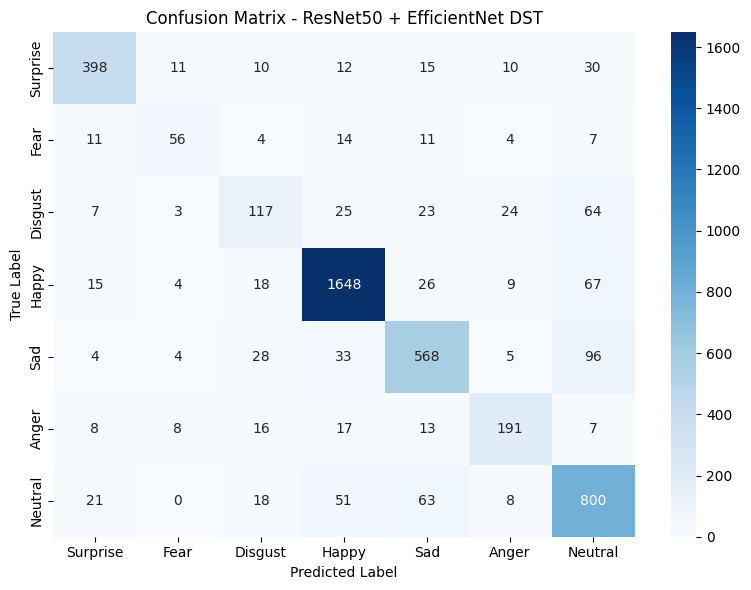

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================
# Class names for RAF-DB
# =========================
class_names = ["Surprise", "Fear", "Disgust", "Happy", "Sad", "Anger", "Neutral"]

# =========================
# Confusion matrix for best model
# Best model = ResNet50 + EfficientNet DST
# =========================
cm = confusion_matrix(y_true, resnet_eff_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix - ResNet50 + EfficientNet DST")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

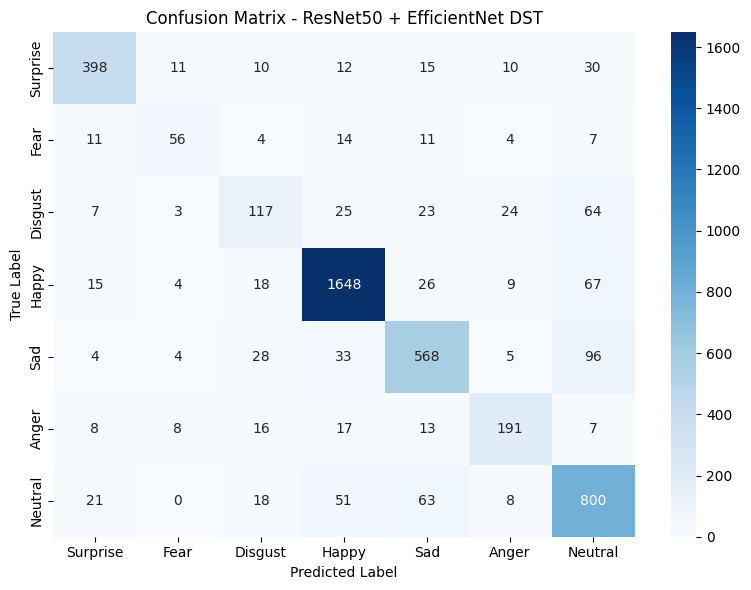

Saved: /kaggle/working/confusion_matrix_resnet_eff_dst.png


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = ["Surprise", "Fear", "Disgust", "Happy", "Sad", "Anger", "Neutral"]

cm = confusion_matrix(y_true, resnet_eff_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix - ResNet50 + EfficientNet DST")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig("/kaggle/working/confusion_matrix_resnet_eff_dst.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: /kaggle/working/confusion_matrix_resnet_eff_dst.png")

In [22]:
from sklearn.metrics import classification_report
import pandas as pd

# RAF-DB class names
class_names = ["Surprise", "Fear", "Disgust", "Happy", "Sad", "Anger", "Neutral"]

# =========================
# Classification report for best DST model
# =========================
report = classification_report(
    y_true,
    resnet_eff_preds,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("Classification Report - ResNet50 + EfficientNet DST")
print(report_df)

Classification Report - ResNet50 + EfficientNet DST
              precision    recall  f1-score      support
Surprise       0.857759  0.818930  0.837895   486.000000
Fear           0.651163  0.523364  0.580311   107.000000
Disgust        0.554502  0.444867  0.493671   263.000000
Happy          0.915556  0.922216  0.918874  1787.000000
Sad            0.789986  0.769648  0.779684   738.000000
Anger          0.760956  0.734615  0.747554   260.000000
Neutral        0.746965  0.832466  0.787402   961.000000
accuracy       0.820947  0.820947  0.820947     0.820947
macro avg      0.753841  0.720872  0.735056  4602.000000
weighted avg   0.818594  0.820947  0.818696  4602.000000


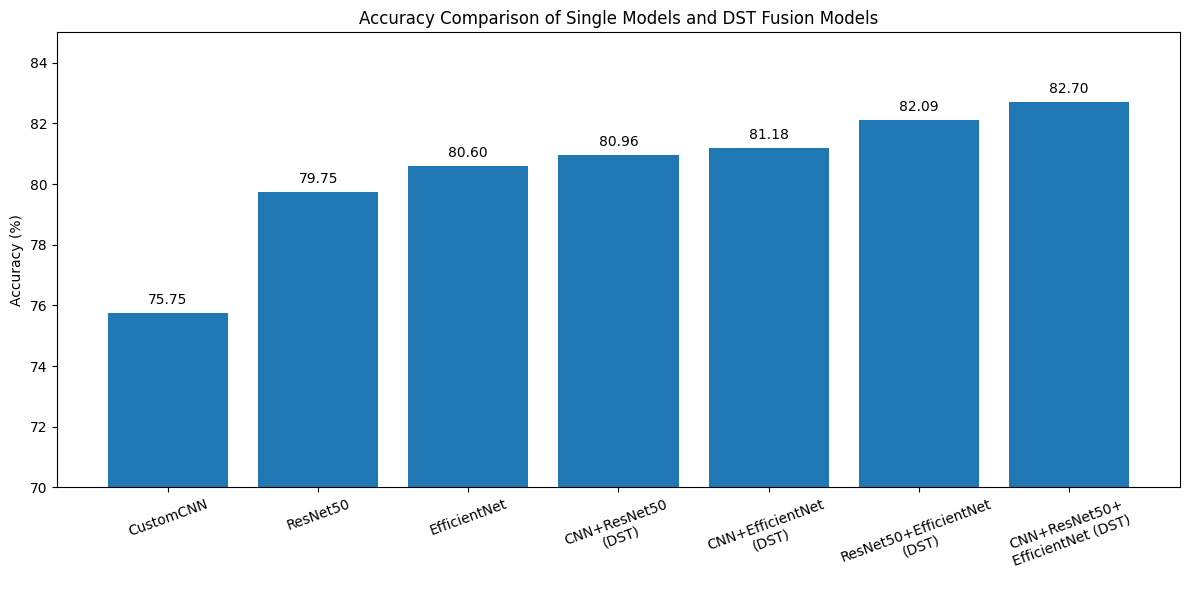

Saved: /kaggle/working/model_accuracy_comparison_70_30.png


In [23]:
import matplotlib.pyplot as plt

model_names = [
    "CustomCNN",
    "ResNet50",
    "EfficientNet",
    "CNN+ResNet50\n(DST)",
    "CNN+EfficientNet\n(DST)",
    "ResNet50+EfficientNet\n(DST)",
    "CNN+ResNet50+\nEfficientNet (DST)"
]

accuracies = [
    75.75,
    79.75,
    80.60,
    cnn_resnet_acc,
    cnn_eff_acc,
    resnet_eff_acc,
    cnn_resnet_eff_acc
]

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, accuracies)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f"{acc:.2f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Accuracy Comparison of Single Models and DST Fusion Models")
plt.ylabel("Accuracy (%)")
plt.ylim(70, 85)
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("/kaggle/working/model_accuracy_comparison_70_30.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: /kaggle/working/model_accuracy_comparison_70_30.png")

Random Test Image Path: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train/1/train_02973_aligned.jpg
True Label: 0 - Surprise


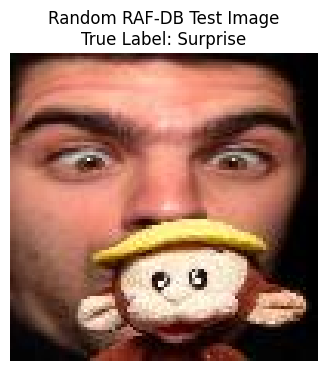

In [24]:
import random
from PIL import Image
import matplotlib.pyplot as plt

# RAF-DB class names
class_names = ["Surprise", "Fear", "Disgust", "Happy", "Sad", "Anger", "Neutral"]

# randomly choose one image from test_df
random_idx = random.randint(0, len(test_df) - 1)

img_path = test_df.loc[random_idx, "image_path"]
true_label = test_df.loc[random_idx, "label"]

print("Random Test Image Path:", img_path)
print("True Label:", true_label, "-", class_names[true_label])

# show image
img = Image.open(img_path).convert("RGB")
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Random RAF-DB Test Image\nTrue Label: {class_names[true_label]}")
plt.axis("off")
plt.show()

In [25]:
import torch

# =========================
# Apply model-specific test transforms
# =========================
cnn_input = cnn_test_transform(img).unsqueeze(0).to(device)
resnet_input = resnet_test_transform(img).unsqueeze(0).to(device)
eff_input = eff_test_transform(img).unsqueeze(0).to(device)

print("CNN input shape      :", cnn_input.shape)
print("ResNet input shape   :", resnet_input.shape)
print("EfficientNet shape   :", eff_input.shape)

CNN input shape      : torch.Size([1, 3, 96, 96])
ResNet input shape   : torch.Size([1, 3, 96, 96])
EfficientNet shape   : torch.Size([1, 3, 224, 224])


In [26]:
import torch
import torch.nn.functional as F
import numpy as np

# =========================
# Load saved best models
# =========================

# ---- CNN ----
cnn_model.load_state_dict(torch.load("/kaggle/working/best_cnn_70_30.pth"))
cnn_model.eval()

# ---- ResNet50 ----
resnet_model = ResNet50Scratch(num_classes=7).to(device)
resnet_model.load_state_dict(torch.load("/kaggle/working/best_resnet50_70_30.pth"))
resnet_model.eval()

# ---- EfficientNet ----
efficientnet_model = EfficientNet_B0(num_classes=7).to(device)
efficientnet_model.load_state_dict(torch.load("/kaggle/working/best_efficientnet_70_30.pth"))
efficientnet_model.eval()

# =========================
# Get softmax probabilities for this image
# =========================
with torch.no_grad():
    cnn_prob = F.softmax(cnn_model(cnn_input), dim=1).cpu().numpy()[0]
    resnet_prob = F.softmax(resnet_model(resnet_input), dim=1).cpu().numpy()[0]
    eff_prob = F.softmax(efficientnet_model(eff_input), dim=1).cpu().numpy()[0]

print("CNN probabilities shape       :", cnn_prob.shape)
print("ResNet50 probabilities shape  :", resnet_prob.shape)
print("EfficientNet probabilities shape:", eff_prob.shape)

# predicted classes
cnn_pred = np.argmax(cnn_prob)
resnet_pred = np.argmax(resnet_prob)
eff_pred = np.argmax(eff_prob)

print("\nCNN Prediction       :", class_names[cnn_pred])
print("ResNet50 Prediction  :", class_names[resnet_pred])
print("EfficientNet Prediction:", class_names[eff_pred])

CNN probabilities shape       : (7,)
ResNet50 probabilities shape  : (7,)
EfficientNet probabilities shape: (7,)

CNN Prediction       : Surprise
ResNet50 Prediction  : Surprise
EfficientNet Prediction: Surprise


In [27]:
import numpy as np
import pandas as pd

# =========================
# DST helper functions
# =========================
def softmax_to_mass(prob_vector):
    return {i: float(p) for i, p in enumerate(prob_vector)}

def dst_combine_two(m1, m2, num_classes=7):
    combined = {i: 0.0 for i in range(num_classes)}
    conflict = 0.0

    for i in range(num_classes):
        for j in range(num_classes):
            if i == j:
                combined[i] += m1[i] * m2[j]
            else:
                conflict += m1[i] * m2[j]

    if conflict < 1.0:
        for i in range(num_classes):
            combined[i] = combined[i] / (1.0 - conflict)

    return combined

# =========================
# DST fusion: ResNet50 + EfficientNet
# =========================
m1 = softmax_to_mass(resnet_prob)
m2 = softmax_to_mass(eff_prob)

dst_mass = dst_combine_two(m1, m2, num_classes=7)
dst_prob = np.array([dst_mass[i] for i in range(7)])

dst_pred = np.argmax(dst_prob)

print("DST Fusion Prediction:", class_names[dst_pred])

# =========================
# Final probability table
# =========================
prob_df = pd.DataFrame({
    "Emotion": class_names,
    "CNN": cnn_prob,
    "ResNet50": resnet_prob,
    "EfficientNet": eff_prob,
    "DST Fusion": dst_prob
})

print("\nProbability Table for Random RAF-DB Image:")
print(prob_df)

DST Fusion Prediction: Surprise

Probability Table for Random RAF-DB Image:
    Emotion       CNN  ResNet50  EfficientNet    DST Fusion
0  Surprise  0.951005  0.787980      0.976340  9.986732e-01
1      Fear  0.034902  0.043674      0.016231  9.201699e-04
2   Disgust  0.001668  0.025726      0.000094  3.135259e-06
3     Happy  0.000148  0.019730      0.000182  4.649652e-06
4       Sad  0.000706  0.024131      0.000004  1.122128e-07
5     Anger  0.009449  0.062352      0.001806  1.461424e-04
6   Neutral  0.002122  0.036407      0.005344  2.525660e-04


In [28]:
import numpy as np
import pandas as pd

# =========================
# DST helper functions
# =========================
def softmax_to_mass(prob_vector):
    return {i: float(p) for i, p in enumerate(prob_vector)}

def dst_combine_two(m1, m2, num_classes=7):
    combined = {i: 0.0 for i in range(num_classes)}
    conflict = 0.0

    for i in range(num_classes):
        for j in range(num_classes):
            if i == j:
                combined[i] += m1[i] * m2[j]
            else:
                conflict += m1[i] * m2[j]

    if conflict < 1.0:
        for i in range(num_classes):
            combined[i] = combined[i] / (1.0 - conflict)

    return combined

def fuse_two_probs(prob1, prob2):
    m1 = softmax_to_mass(prob1)
    m2 = softmax_to_mass(prob2)
    fused_mass = dst_combine_two(m1, m2, num_classes=7)
    return np.array([fused_mass[i] for i in range(7)])

# =========================
# Pairwise DST for this image
# =========================
cnn_resnet_dst = fuse_two_probs(cnn_prob, resnet_prob)
cnn_eff_dst = fuse_two_probs(cnn_prob, eff_prob)
resnet_eff_dst = fuse_two_probs(resnet_prob, eff_prob)

# =========================
# Triple DST for this image
# =========================
temp_dst = fuse_two_probs(cnn_prob, resnet_prob)
cnn_resnet_eff_dst = fuse_two_probs(temp_dst, eff_prob)

# =========================
# Predictions
# =========================
cnn_pred = np.argmax(cnn_prob)
resnet_pred = np.argmax(resnet_prob)
eff_pred = np.argmax(eff_prob)

cnn_resnet_pred = np.argmax(cnn_resnet_dst)
cnn_eff_pred = np.argmax(cnn_eff_dst)
resnet_eff_pred = np.argmax(resnet_eff_dst)
cnn_resnet_eff_pred = np.argmax(cnn_resnet_eff_dst)

print("True Label:", class_names[true_label])
print("CNN Prediction                     :", class_names[cnn_pred])
print("ResNet50 Prediction                :", class_names[resnet_pred])
print("EfficientNet Prediction            :", class_names[eff_pred])
print("CNN + ResNet50 DST Prediction      :", class_names[cnn_resnet_pred])
print("CNN + EfficientNet DST Prediction  :", class_names[cnn_eff_pred])
print("ResNet50 + EfficientNet DST Prediction :", class_names[resnet_eff_pred])
print("CNN + ResNet50 + EfficientNet DST Prediction :", class_names[cnn_resnet_eff_pred])

# =========================
# Full probability table
# =========================
prob_df = pd.DataFrame({
    "Emotion": class_names,
    "CNN": cnn_prob,
    "ResNet50": resnet_prob,
    "EfficientNet": eff_prob,
    "CNN+ResNet DST": cnn_resnet_dst,
    "CNN+EffNet DST": cnn_eff_dst,
    "ResNet+EffNet DST": resnet_eff_dst,
    "CNN+ResNet+EffNet DST": cnn_resnet_eff_dst
})

print("\nFull Probability Table for Random RAF-DB Image:")
print(prob_df)

True Label: Surprise
CNN Prediction                     : Surprise
ResNet50 Prediction                : Surprise
EfficientNet Prediction            : Surprise
CNN + ResNet50 DST Prediction      : Surprise
CNN + EfficientNet DST Prediction  : Surprise
ResNet50 + EfficientNet DST Prediction : Surprise
CNN + ResNet50 + EfficientNet DST Prediction : Surprise

Full Probability Table for Random RAF-DB Image:
    Emotion       CNN  ResNet50  EfficientNet  CNN+ResNet DST  CNN+EffNet DST  \
0  Surprise  0.951005  0.787980      0.976340        0.997002    9.993594e-01   
1      Fear  0.034902  0.043674      0.016231        0.002028    6.097076e-04   
2   Disgust  0.001668  0.025726      0.000094        0.000057    1.685774e-07   
3     Happy  0.000148  0.019730      0.000182        0.000004    2.892530e-08   
4       Sad  0.000706  0.024131      0.000004        0.000023    2.721624e-09   
5     Anger  0.009449  0.062352      0.001806        0.000784    1.836273e-05   
6   Neutral  0.002122  0.03

In [29]:
# make a clean rounded copy for report display
prob_df_display = prob_df.copy()

# round all probability columns to 6 decimals
for col in prob_df_display.columns[1:]:
    prob_df_display[col] = prob_df_display[col].astype(float).round(6)

print("Formatted Probability Table:")
print(prob_df_display)

Formatted Probability Table:
    Emotion       CNN  ResNet50  EfficientNet  CNN+ResNet DST  CNN+EffNet DST  \
0  Surprise  0.951005  0.787980      0.976340        0.997002        0.999359   
1      Fear  0.034902  0.043674      0.016231        0.002028        0.000610   
2   Disgust  0.001668  0.025726      0.000094        0.000057        0.000000   
3     Happy  0.000148  0.019730      0.000182        0.000004        0.000000   
4       Sad  0.000706  0.024131      0.000004        0.000023        0.000000   
5     Anger  0.009449  0.062352      0.001806        0.000784        0.000018   
6   Neutral  0.002122  0.036407      0.005344        0.000103        0.000012   

   ResNet+EffNet DST  CNN+ResNet+EffNet DST  
0           0.998673               0.999964  
1           0.000920               0.000034  
2           0.000003               0.000000  
3           0.000005               0.000000  
4           0.000000               0.000000  
5           0.000146               0.000001  


In [30]:
from sklearn.metrics import classification_report

# RAF-DB class names
class_names = ["Surprise", "Fear", "Disgust", "Happy", "Sad", "Anger", "Neutral"]

# report-style output
report_text = classification_report(
    y_true,
    resnet_eff_preds,
    target_names=class_names,
    digits=2
)

print("Classification Report - ResNet50 + EfficientNet DST\n")
print(report_text)

Classification Report - ResNet50 + EfficientNet DST

              precision    recall  f1-score   support

    Surprise       0.86      0.82      0.84       486
        Fear       0.65      0.52      0.58       107
     Disgust       0.55      0.44      0.49       263
       Happy       0.92      0.92      0.92      1787
         Sad       0.79      0.77      0.78       738
       Anger       0.76      0.73      0.75       260
     Neutral       0.75      0.83      0.79       961

    accuracy                           0.82      4602
   macro avg       0.75      0.72      0.74      4602
weighted avg       0.82      0.82      0.82      4602



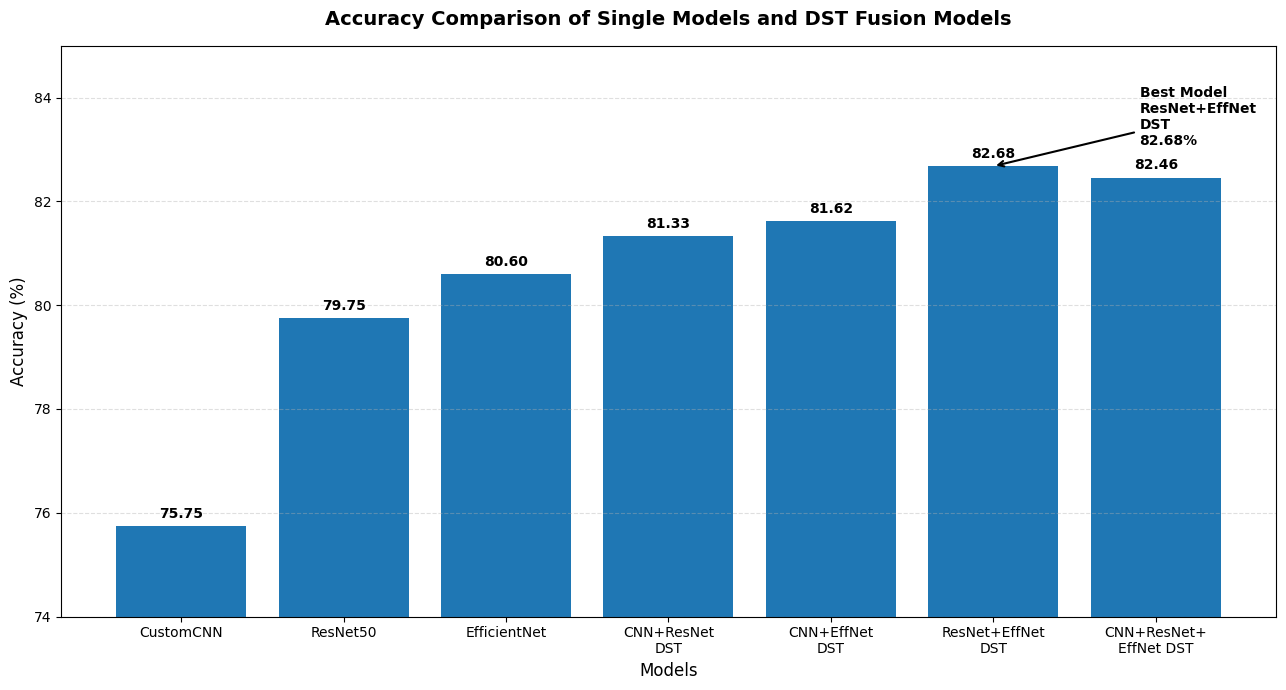

Saved: /kaggle/working/beautiful_accuracy_comparison_fixed.png


In [31]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Data
# =========================
model_names = [
    "CustomCNN",
    "ResNet50",
    "EfficientNet",
    "CNN+ResNet\nDST",
    "CNN+EffNet\nDST",
    "ResNet+EffNet\nDST",
    "CNN+ResNet+\nEffNet DST"
]

accuracies = [
    75.75,
    79.75,
    80.60,
    81.33,
    81.62,
    82.68,
    82.46
]

best_idx = np.argmax(accuracies)
best_acc = accuracies[best_idx]
best_model = model_names[best_idx]

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.bar(model_names, accuracies)

# highlight best bar
bars[best_idx].set_linewidth(2)

# value labels above bars
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.10,
        f"{acc:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# move annotation to the side so it doesn't overlap
ax.annotate(
    f"Best Model\n{best_model}\n{best_acc:.2f}%",
    xy=(best_idx, best_acc),
    xytext=(best_idx + 0.9, best_acc + 0.4),   # moved right side
    ha='left',
    fontsize=10,
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', lw=1.5)
)

ax.set_title("Accuracy Comparison of Single Models and DST Fusion Models",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Models", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)

# give more top space
ax.set_ylim(74, 85)

ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.savefig("/kaggle/working/beautiful_accuracy_comparison_fixed.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Saved: /kaggle/working/beautiful_accuracy_comparison_fixed.png")

Uploaded image path: /kaggle/input/datasets/ankansamanta980/surprise-img/surprise_img.jpeg


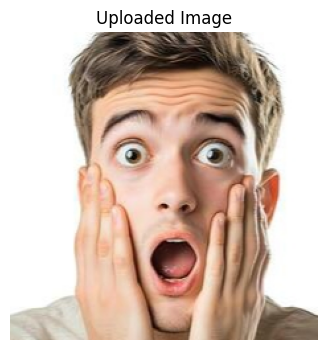

In [32]:
from PIL import Image
import matplotlib.pyplot as plt

# uploaded image path
uploaded_img_path = "/kaggle/input/datasets/ankansamanta980/surprise-img/surprise_img.jpeg"

# load image
uploaded_img = Image.open(uploaded_img_path).convert("RGB")

print("Uploaded image path:", uploaded_img_path)

# display image
plt.figure(figsize=(4, 4))
plt.imshow(uploaded_img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

In [33]:
import torch

# =========================
# Apply model-specific test transforms
# =========================
uploaded_cnn_input = cnn_test_transform(uploaded_img).unsqueeze(0).to(device)
uploaded_resnet_input = resnet_test_transform(uploaded_img).unsqueeze(0).to(device)
uploaded_eff_input = eff_test_transform(uploaded_img).unsqueeze(0).to(device)

print("CNN input shape       :", uploaded_cnn_input.shape)
print("ResNet50 input shape  :", uploaded_resnet_input.shape)
print("EfficientNet input shape :", uploaded_eff_input.shape)

CNN input shape       : torch.Size([1, 3, 96, 96])
ResNet50 input shape  : torch.Size([1, 3, 96, 96])
EfficientNet input shape : torch.Size([1, 3, 224, 224])


In [34]:
import torch
import torch.nn.functional as F
import numpy as np

# RAF-DB class names
class_names = ["Surprise", "Fear", "Disgust", "Happy", "Sad", "Anger", "Neutral"]

# =========================
# Load saved best models
# =========================

# ---- CNN ----
cnn_model.load_state_dict(torch.load("/kaggle/working/best_cnn_70_30.pth"))
cnn_model.eval()

# ---- ResNet50 ----
resnet_model = ResNet50Scratch(num_classes=7).to(device)
resnet_model.load_state_dict(torch.load("/kaggle/working/best_resnet50_70_30.pth"))
resnet_model.eval()

# ---- EfficientNet ----
efficientnet_model = EfficientNet_B0(num_classes=7).to(device)
efficientnet_model.load_state_dict(torch.load("/kaggle/working/best_efficientnet_70_30.pth"))
efficientnet_model.eval()

# =========================
# Get softmax probabilities for uploaded image
# =========================
with torch.no_grad():
    uploaded_cnn_prob = F.softmax(cnn_model(uploaded_cnn_input), dim=1).cpu().numpy()[0]
    uploaded_resnet_prob = F.softmax(resnet_model(uploaded_resnet_input), dim=1).cpu().numpy()[0]
    uploaded_eff_prob = F.softmax(efficientnet_model(uploaded_eff_input), dim=1).cpu().numpy()[0]

print("CNN probabilities shape       :", uploaded_cnn_prob.shape)
print("ResNet50 probabilities shape  :", uploaded_resnet_prob.shape)
print("EfficientNet probabilities shape:", uploaded_eff_prob.shape)

# predicted classes
uploaded_cnn_pred = np.argmax(uploaded_cnn_prob)
uploaded_resnet_pred = np.argmax(uploaded_resnet_prob)
uploaded_eff_pred = np.argmax(uploaded_eff_prob)

print("\nCNN Prediction        :", class_names[uploaded_cnn_pred])
print("ResNet50 Prediction   :", class_names[uploaded_resnet_pred])
print("EfficientNet Prediction:", class_names[uploaded_eff_pred])

CNN probabilities shape       : (7,)
ResNet50 probabilities shape  : (7,)
EfficientNet probabilities shape: (7,)

CNN Prediction        : Surprise
ResNet50 Prediction   : Fear
EfficientNet Prediction: Surprise


In [35]:
import numpy as np
import pandas as pd

# =========================
# DST helper functions
# =========================
def softmax_to_mass(prob_vector):
    return {i: float(p) for i, p in enumerate(prob_vector)}

def dst_combine_two(m1, m2, num_classes=7):
    combined = {i: 0.0 for i in range(num_classes)}
    conflict = 0.0

    for i in range(num_classes):
        for j in range(num_classes):
            if i == j:
                combined[i] += m1[i] * m2[j]
            else:
                conflict += m1[i] * m2[j]

    if conflict < 1.0:
        for i in range(num_classes):
            combined[i] = combined[i] / (1.0 - conflict)

    return combined

def fuse_two_probs(prob1, prob2):
    m1 = softmax_to_mass(prob1)
    m2 = softmax_to_mass(prob2)
    fused_mass = dst_combine_two(m1, m2, num_classes=7)
    return np.array([fused_mass[i] for i in range(7)])

# =========================
# Pairwise DST for uploaded image
# =========================
uploaded_cnn_resnet_dst = fuse_two_probs(uploaded_cnn_prob, uploaded_resnet_prob)
uploaded_cnn_eff_dst = fuse_two_probs(uploaded_cnn_prob, uploaded_eff_prob)
uploaded_resnet_eff_dst = fuse_two_probs(uploaded_resnet_prob, uploaded_eff_prob)

# =========================
# Triple DST for uploaded image
# =========================
temp_dst = fuse_two_probs(uploaded_cnn_prob, uploaded_resnet_prob)
uploaded_cnn_resnet_eff_dst = fuse_two_probs(temp_dst, uploaded_eff_prob)

# =========================
# Predictions
# =========================
uploaded_cnn_resnet_pred = np.argmax(uploaded_cnn_resnet_dst)
uploaded_cnn_eff_pred = np.argmax(uploaded_cnn_eff_dst)
uploaded_resnet_eff_pred = np.argmax(uploaded_resnet_eff_dst)
uploaded_cnn_resnet_eff_pred = np.argmax(uploaded_cnn_resnet_eff_dst)

print("CNN Prediction                         :", class_names[uploaded_cnn_pred])
print("ResNet50 Prediction                    :", class_names[uploaded_resnet_pred])
print("EfficientNet Prediction                :", class_names[uploaded_eff_pred])
print("CNN + ResNet50 DST Prediction          :", class_names[uploaded_cnn_resnet_pred])
print("CNN + EfficientNet DST Prediction      :", class_names[uploaded_cnn_eff_pred])
print("ResNet50 + EfficientNet DST Prediction :", class_names[uploaded_resnet_eff_pred])
print("CNN + ResNet50 + EfficientNet DST Prediction :", class_names[uploaded_cnn_resnet_eff_pred])

# =========================
# Full probability table
# =========================
uploaded_prob_df = pd.DataFrame({
    "Emotion": class_names,
    "CNN": uploaded_cnn_prob,
    "ResNet50": uploaded_resnet_prob,
    "EfficientNet": uploaded_eff_prob,
    "CNN+ResNet DST": uploaded_cnn_resnet_dst,
    "CNN+EffNet DST": uploaded_cnn_eff_dst,
    "ResNet+EffNet DST": uploaded_resnet_eff_dst,
    "CNN+ResNet+EffNet DST": uploaded_cnn_resnet_eff_dst
})

print("\nFull Probability Table for Uploaded Image:")
print(uploaded_prob_df)

CNN Prediction                         : Surprise
ResNet50 Prediction                    : Fear
EfficientNet Prediction                : Surprise
CNN + ResNet50 DST Prediction          : Surprise
CNN + EfficientNet DST Prediction      : Surprise
ResNet50 + EfficientNet DST Prediction : Surprise
CNN + ResNet50 + EfficientNet DST Prediction : Surprise

Full Probability Table for Uploaded Image:
    Emotion       CNN  ResNet50  EfficientNet  CNN+ResNet DST  CNN+EffNet DST  \
0  Surprise  0.786650  0.277620      0.597402        0.865038        0.963881   
1      Fear  0.065699  0.293393      0.096762        0.076350        0.013039   
2   Disgust  0.021298  0.046536      0.001315        0.003926        0.000057   
3     Happy  0.013208  0.040432      0.000303        0.002115        0.000008   
4       Sad  0.034593  0.045862      0.158795        0.006284        0.011267   
5     Anger  0.039486  0.275968      0.111121        0.043162        0.008999   
6   Neutral  0.039065  0.020188      